In [1]:
# If you are working in colab, uncomment these lines to install dependencies
!pip install esm@git+https://github.com/Biohub/esm.git@c94ed8d
!pip install matplotlib
!pip install seaborn

  Cloning https://github.com/Biohub/esm.git (to revision c94ed8d) to /tmp/pip-install-te7818ae/esm_ff97880013494492ba70a20b0bd9d7ed
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/esm.git /tmp/pip-install-te7818ae/esm_ff97880013494492ba70a20b0bd9d7ed
  Running command git checkout -q c94ed8d
  Resolved https://github.com/Biohub/esm.git to commit c94ed8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Biohub/transformers.git (to revision 3a8956fb4d4ea16b0ec8e71deef2c2909b6a5cbf) to /tmp/pip-install-te7818ae/transformers_98eec00dede34854a3592a0494314e0c
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/transformers.git /tmp/pip-install-te7818ae/transformers_98eec00dede34854a3592a0494314e0c
  Running command git rev-parse -q --verify 'sha^3a8956fb4d4ea16b0ec8e71deef2c2909b6a5cbf'
  Running command git fetch -q h

In [2]:
from pathlib import Path
import time
import pandas as pd
from esm.sdk import esmc_client
from esm.sdk import batch_executor
from esm.sdk.api import ESMCInferenceClient, ESMProtein, LogitsConfig, LogitsOutput
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

In [ ]:
# get the current directory
current_dir = Path.cwd()

# path to the processed data folder
processed_data_folder = current_dir.parents[1] / "data" / "processed"

In [ ]:
# load the combined features dataframe
df_final = pd.read_pickle(processed_data_folder / "binding_region_combined_features_expanded.pkl")

df_final.columns

Index(['uniprot_id', 'binding_region_seq', 'start_pos', 'end_pos', 'relasa',
       'plddt', 'sec', 'binding_mode', 'scd', 'shd', 'fcr', 'avg_plddt',
       'avg_relasa', 'aa_freq_A', 'aa_freq_C', 'aa_freq_D', 'aa_freq_E',
       'aa_freq_F', 'aa_freq_G', 'aa_freq_H', 'aa_freq_I', 'aa_freq_K',
       'aa_freq_L', 'aa_freq_M', 'aa_freq_N', 'aa_freq_P', 'aa_freq_Q',
       'aa_freq_R', 'aa_freq_S', 'aa_freq_T', 'aa_freq_V', 'aa_freq_W',
       'aa_freq_Y', 'ss_freq_B', 'ss_freq_E', 'ss_freq_G', 'ss_freq_H',
       'ss_freq_I', 'ss_freq_P', 'ss_freq_S', 'ss_freq_T', 'ss_freq_C',
       'ss3_freq_H', 'ss3_freq_E', 'ss3_freq_C'],
      dtype='str')

In [ ]:
# keep only the sequence and the label columns
df_final = df_final[["binding_region_seq", "binding_mode"]]
df_final.head()

,binding_region_seq,binding_mode
0,MDDREDLVYQAKLAEQAERYDEMVESMKKVAG,disorder_to_order
1,FDDAIAELDTLNED,disorder_to_order
2,QAELHPLPQLKDATSNEQ,disorder_to_order
3,LFDDLTSSYKAERQREKKKEL,disorder_to_order
4,NSTPPPTQLSKIKYSGGPQIVKKERRQSSSRFNLSKNRELQKLP,disorder_to_order


In [ ]:
df_final.value_counts

<bound method DataFrame.value_counts of                                       binding_region_seq       binding_mode
0                       MDDREDLVYQAKLAEQAERYDEMVESMKKVAG  disorder_to_order
1                                         FDDAIAELDTLNED  disorder_to_order
2                                     QAELHPLPQLKDATSNEQ  disorder_to_order
3                                  LFDDLTSSYKAERQREKKKEL  disorder_to_order
4           NSTPPPTQLSKIKYSGGPQIVKKERRQSSSRFNLSKNRELQKLP  disorder_to_order
...                                                  ...                ...
11824               EPSVGQVARVDVSSKVEVVWADNSKTIILPQHLYNI  context_dependent
11825                       GTCEECSIDEDCKSNNGRWHCQCKQDFN  context_dependent
11826  AEICPSFQRVIETLLMDTPSSYEAAMELFSPDQDMREAGAQLKKLV...  context_dependent
11827                                         QKDVVHLDIS  context_dependent
11828  GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...  context_dependent

[11821 rows x 2 columns]>

In [ ]:
# make a smaller test dataframe with 1000 samples with all 3 classes represented
df_test = df_final.groupby("binding_mode").sample(n=30, random_state=42)
df_test["binding_mode"].value_counts()

# save the test dataframe as a csv file
df_test.to_csv(processed_data_folder / "test" / "binding_region_test.csv", index=False)

In [4]:
df_test = pd.read_csv("binding_region_test.csv")
df_test.rename(columns={"binding_region_seq": "sequence"}, inplace=True)
df_test.head()

,sequence,binding_mode
0,ECEYTDWKSSGAL,context_dependent
1,ETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTE,context_dependent
2,LTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAELQ...,context_dependent
3,SGRLVLRPWIRELILGSETPSSPRAGQLLEVLQDAEAAVAGPSHAP...,context_dependent
4,AIGGKDVSLFLFRALGKILYCKRASLTELDSPRLPSHLSEYERDTL...,context_dependent


In [8]:
df_full = pd.read_csv("binding_region_combined_features.csv")
df_full.rename(columns={"binding_region_seq": "sequence"}, inplace=True)
df_full = df_full[["sequence", "binding_mode"]]
df_full = df_full.sample(frac=1, random_state=42).reset_index(drop=True)
df_full.head()

,sequence,binding_mode
0,QADTPALSLIAETVEDMVKKNLPPASSPGYGMTTGNNPMSGTTTPT...,disorder_to_disorder
1,LLSFLRGSSACCSTRVRRQLD,disorder_to_order
2,MHPNNSHHTM,context_dependent
3,ILAVLAGLLLLAVLVFVMYRMGFFKRVRPPQEEQEREQLQPHENGE...,disorder_to_disorder
4,FEEQENETVVVKEKMVGGIAQIIAAQEEMLRKERELEEARKKLAQI...,disorder_to_disorder


In [3]:
from getpass import getpass

token = getpass("Token from Biohub: ")

Token from Biohub: ··········


In [9]:


model = esmc_client(model="esmc-300m-2024-12", url="https://biohub.ai", token=token)

In [35]:


EMBEDDING_CONFIG = LogitsConfig(
    sequence=True, return_embeddings=False, return_hidden_states=False, return_mean_hidden_states=True
)


def embed_sequence(model: ESMCInferenceClient, sequence: str) -> LogitsOutput:
    protein = ESMProtein(sequence=sequence)
    protein_tensor = model.encode(protein)
    output = model.logits(protein_tensor, EMBEDDING_CONFIG)
    #mean_embeddings = torch.mean(output.hidden_states.float(), dim=-2).squeeze()
    return output.mean_hidden_state.float().squeeze()

In [36]:
# batch_executor handles retries and parallelization automatically
# This may take a few minutes to run

all_sequences = df_full["sequence"].tolist()
BATCH_SIZE = 500
outputs = []

# Processing in batches to not exceet rquest limit of 750
for i in range(0, len(all_sequences), BATCH_SIZE):
  chunk = all_sequences[i:i+BATCH_SIZE]
  print(f"Processing batch {i//BATCH_SIZE + 1} of {len(all_sequences) // BATCH_SIZE + 1}")

  with batch_executor() as executor:
    chunk_outputs = executor.execute_batch(
        user_func=embed_sequence, model=model, sequence=chunk
    )
    outputs.extend(chunk_outputs)

    # cool down
    if i + BATCH_SIZE < len(all_sequences):
      time.sleep(60)

Processing batch 1 of 24


Processing  100%|████████████████████████| 500/500 [Elapsed: 00:12 | Remaining: 00:00] , Success=500 Fail=0 Retry=0


Processing batch 2 of 24


Processing  100%|████████████████████████| 500/500 [Elapsed: 00:09 | Remaining: 00:00] , Success=500 Fail=0 Retry=0


Processing batch 3 of 24


...

Processing  100%|████████████████████████| 500/500 [Elapsed: 00:10 | Remaining: 00:00] , Success=499 Fail=1 Retry=0


Processing batch 23 of 24


Processing  100%|████████████████████████| 500/500 [Elapsed: 00:12 | Remaining: 00:00] , Success=500 Fail=0 Retry=0


Processing batch 24 of 24


Processing  100%|████████████████████████| 321/321 [Elapsed: 00:07 | Remaining: 00:00] , Success=321 Fail=0 Retry=0


In [39]:
outputs

[tensor([[ 1.4746e-01, -1.9922e-01, -1.7773e-01,  ..., -5.9814e-02,
           2.4121e-01, -2.6367e-01],
         [-1.3574e-01, -2.7930e-01, -2.6953e-01,  ..., -2.0996e-01,
           7.2754e-02, -5.5469e-01],
         [ 5.7129e-02, -2.0215e-01, -1.0010e-01,  ..., -2.0703e-01,
           8.3008e-02, -4.3359e-01],
         ...,
         [-2.0250e+01,  5.0000e+00,  5.0625e+00,  ..., -8.4375e+00,
           8.9062e-01,  8.3203e-01],
         [-1.3562e+01,  6.5938e+00,  6.3672e-01,  ..., -2.9750e+01,
          -1.1000e+01, -1.2750e+01],
         [-7.9346e-03,  2.3682e-02,  1.4648e-02,  ..., -1.4832e-02,
          -1.5564e-02, -1.8066e-02]]),
 tensor([[ 4.0430e-01,  5.0293e-02,  3.2422e-01,  ..., -1.0303e-01,
           4.3750e-01, -3.3789e-01],
         [-1.7188e-01,  9.7046e-03, -1.7944e-02,  ..., -1.4844e-01,
           1.0547e-01, -3.8672e-01],
         [ 2.0447e-03,  1.4453e-01,  7.0801e-02,  ..., -4.2578e-01,
           2.0020e-01, -4.9805e-01],
         ...,
         [ 1.1016e+00, -4

TypeError: expected Tensor as element 1687 in argument 0, but got ValueError

In [43]:
# Find the index and the data type of anything that is NOT a torch.Tensor
failed_elements = [
    {"index": idx, "type": type(item).__name__, "value": item}
    for idx, item in enumerate(outputs)
    if not isinstance(item, torch.Tensor)
]

print("Found non-tensor elements:")
for error in failed_elements:
    print(f"Index {error['index']}: Found {error['type']} -> '{error['value']}'")

Found non-tensor elements:
Index 1687: Found ValueError -> 'Input must be an ESMProteinTensor instance, but received an ESMProteinError instead: 500 Failed to submit request to encode. Error: [Errno 9] Bad file descriptor'
Index 8761: Found ValueError -> 'Input must be an ESMProteinTensor instance, but received an ESMProteinError instead: 500 Failed to submit request to encode. Error: [Errno 9] Bad file descriptor'
Index 9896: Found AttributeError -> ''ESMProteinError' object has no attribute 'mean_hidden_state''
Index 9991: Found ValueError -> 'Input must be an ESMProteinTensor instance, but received an ESMProteinError instead: 500 Failed to submit request to encode. Error: [Errno 9] Bad file descriptor'
Index 10913: Found AttributeError -> ''ESMProteinError' object has no attribute 'mean_hidden_state''


In [51]:
df_full

,sequence,binding_mode
0,QADTPALSLIAETVEDMVKKNLPPASSPGYGMTTGNNPMSGTTTPT...,disorder_to_disorder
1,LLSFLRGSSACCSTRVRRQLD,disorder_to_order
2,MHPNNSHHTM,context_dependent
3,ILAVLAGLLLLAVLVFVMYRMGFFKRVRPPQEEQEREQLQPHENGE...,disorder_to_disorder
4,FEEQENETVVVKEKMVGGIAQIIAAQEEMLRKERELEEARKKLAQI...,disorder_to_disorder
...,...,...
11816,HGKNNGEDEDMVSSERTCTLAIIKPDAVAHGKTDEIIMKIQEAGFE...,disorder_to_disorder
11817,SADMLNVTLQGPTLNGTFAQSK,disorder_to_disorder
11818,MGRDTRSRSRSAGRRGRRRQSQSGSRSRSRSHGRRNRRRREDEGRR...,disorder_to_disorder
11819,YPKPDTQQMIPFQP,disorder_to_order


In [52]:
df_full.to_csv("initial_input_embeddings.csv", index=False)
df_mod = df_full.drop([1687, 8761, 9896, 9991, 10913])
df_mod.to_csv("final_clean_embeddings_input.csv", index=False)

In [46]:
# 1. Filter out anything that is NOT a valid, healthy tensor
clean_mean_embeddings = [
    item for item in outputs
    if isinstance(item, torch.Tensor) and not (torch.isnan(item).any() or torch.isinf(item).any())
]

# 2. Check the final clean count
print(f"Original length: {len(outputs)}")
print(f"Cleaned length: {len(clean_mean_embeddings)}")

Original length: 11821
Cleaned length: 11816


In [47]:

# Stack so that Layer is the first dimension
esmc_idr_binding_region_tensor = torch.stack(clean_mean_embeddings, dim=1)

# Save to disk
torch.save(esmc_idr_binding_region_tensor, "esmc_idr_binding_region_tensor.pt")

print(esmc_idr_binding_region_tensor.shape)

torch.Size([31, 11816, 960])


In [48]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
!cp /content/esmc_idr_binding_region_tensor.pt "/content/drive/MyDrive/"


In [ ]:
import torch

# 1. Load the file directly as a 3D tensor
all_mean_embeddings = torch.load("viz_embeddings.pt")

# 2. Extract the layer instantly without a list comprehension loop
layer_idx = -1  # Example: Last layer
stacked_mean_embeddings = all_mean_embeddings[layer_idx].float().numpy()

print(stacked_mean_embeddings.shape)
# Output: (num_samples, hidden_size)


In [45]:


# we'll summarize the embeddings using their mean across the sequence dimension
# which allows us to compare embeddings for sequences of different lengths
#all_mean_embeddings = [
#    torch.mean(output.hidden_states.float(), dim=-2).squeeze() for output in outputs
#]

# now we have a list of tensors of [num_layers, hidden_size]
#print("embedding shape [num_layers, hidden_size]:", all_mean_embeddings[0].shape)

embedding shape [num_layers, hidden_size]: torch.Size([31, 960])


In [40]:



N_KMEANS_CLUSTERS = 3

In [41]:
def plot_embeddings_at_layer(all_mean_embeddings: torch.Tensor, layer_idx: int, df_test: pd.DataFrame):
    stacked_mean_embeddings = (
        torch.stack([embedding[layer_idx, :] for embedding in all_mean_embeddings])
        .float()
        .numpy()
    )

    # project all the embeddings to 2D using PCA
    pca = PCA(n_components=2)
    pca.fit(stacked_mean_embeddings)
    projected_mean_embeddings = pca.transform(stacked_mean_embeddings)

    # compute kmeans purity as a measure of how good the clustering is
    kmeans = KMeans(n_clusters=N_KMEANS_CLUSTERS, random_state=0).fit(
        projected_mean_embeddings
    )
    rand_index = adjusted_rand_score(df_test["binding_mode"], kmeans.labels_)

    # plot the clusters
    plt.figure(figsize=(4, 4))
    sns.scatterplot(
        x=projected_mean_embeddings[:, 0],
        y=projected_mean_embeddings[:, 1],
        hue=df_test["binding_mode"],
    )
    plt.title(
        f"PCA of mean embeddings at layer {layer_idx}.\nRand index: {rand_index:.2f}"
    )
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.show()

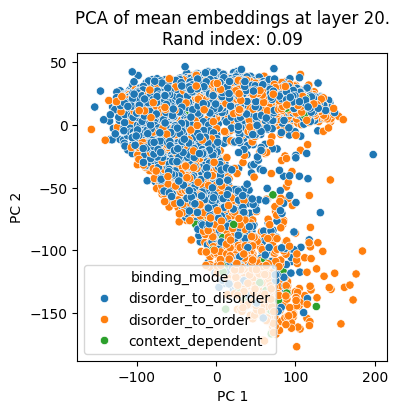

In [ ]:
plot_embeddings_at_layer(all_mean_embeddings=clean_mean_embeddings, layer_idx=20, df_test=df_mod)


In [17]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
from sklearn.manifold import TSNE


In [3]:

all_mean_embeddings = torch.load("esmc_idr_binding_region_tensor.pt")

layer_idx = -1
stacked_mean_embeddings = all_mean_embeddings[layer_idx].float().numpy()

print(stacked_mean_embeddings.shape)  

df = pd.read_csv("final_clean_embeddings_input.csv")
print(df.head())

(11816, 960)
                                            sequence          binding_mode
0  QADTPALSLIAETVEDMVKKNLPPASSPGYGMTTGNNPMSGTTTPT...  disorder_to_disorder
1                              LLSFLRGSSACCSTRVRRQLD     disorder_to_order
2                                         MHPNNSHHTM     context_dependent
3  ILAVLAGLLLLAVLVFVMYRMGFFKRVRPPQEEQEREQLQPHENGE...  disorder_to_disorder
4  FEEQENETVVVKEKMVGGIAQIIAAQEEMLRKERELEEARKKLAQI...  disorder_to_disorder


In [5]:

N_KMEANS_CLUSTERS = 3
for i in range(0, 31):
    layer_idx = i
    stacked_mean_embeddings = all_mean_embeddings[layer_idx].float().numpy()

    # project all the embeddings to 2D using PCA
    pca = PCA(n_components=2)
    pca.fit(stacked_mean_embeddings)
    projected_mean_embeddings = pca.transform(stacked_mean_embeddings)

    # compute kmeans purity as a measure of how good the clustering is
    kmeans = KMeans(n_clusters=N_KMEANS_CLUSTERS, random_state=0).fit(
        projected_mean_embeddings
    )
    rand_index = adjusted_rand_score(df["binding_mode"], kmeans.labels_)

    print(f"Rand index: {rand_index:.2f} for layer {layer_idx}")

Rand index: 0.02 for layer 0
Rand index: 0.00 for layer 1
Rand index: -0.00 for layer 2
Rand index: 0.01 for layer 3
Rand index: 0.01 for layer 4
Rand index: 0.00 for layer 5
Rand index: 0.01 for layer 6
Rand index: -0.00 for layer 7
Rand index: -0.00 for layer 8
Rand index: -0.00 for layer 9
Rand index: 0.00 for layer 10
Rand index: 0.00 for layer 11
Rand index: 0.00 for layer 12
Rand index: 0.00 for layer 13
Rand index: 0.01 for layer 14
Rand index: 0.01 for layer 15
Rand index: 0.02 for layer 16
Rand index: 0.07 for layer 17
Rand index: 0.09 for layer 18
Rand index: 0.08 for layer 19
Rand index: 0.09 for layer 20
Rand index: 0.09 for layer 21
Rand index: 0.09 for layer 22
Rand index: 0.08 for layer 23
Rand index: 0.09 for layer 24
Rand index: 0.08 for layer 25
Rand index: 0.10 for layer 26
Rand index: 0.10 for layer 27
Rand index: 0.08 for layer 28
Rand index: 0.08 for layer 29
Rand index: 0.02 for layer 30


In [14]:
N_KMEANS_CLUSTERS = 3
def plot_embeddings_at_layer_mod(all_mean_embeddings: torch.Tensor, layer_idx: int, df: pd.DataFrame):
    
    stacked_mean_embeddings = all_mean_embeddings[layer_idx].float().numpy()

    # project all the embeddings to 2D using PCA
    pca = PCA(n_components=2)
    pca.fit(stacked_mean_embeddings)
    projected_mean_embeddings = pca.transform(stacked_mean_embeddings)

    # compute kmeans purity as a measure of how good the clustering is
    kmeans = KMeans(n_clusters=N_KMEANS_CLUSTERS, random_state=0).fit(
        projected_mean_embeddings
    )
    rand_index = adjusted_rand_score(df["binding_mode"], kmeans.labels_)

    # plot the clusters
    plt.figure(figsize=(4, 4))
    sns.scatterplot(
        x=projected_mean_embeddings[:, 0],
        y=projected_mean_embeddings[:, 1],
        hue=df["binding_mode"],
    )
    plt.title(
        f"PCA of mean embeddings at layer {layer_idx}.\nRand index: {rand_index:.2f}"
    )
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.show()

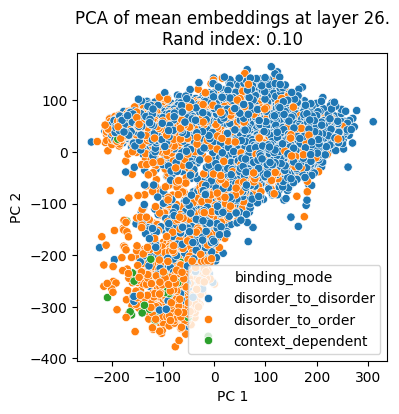

In [15]:
plot_embeddings_at_layer_mod(all_mean_embeddings=all_mean_embeddings, layer_idx=26, df=df)


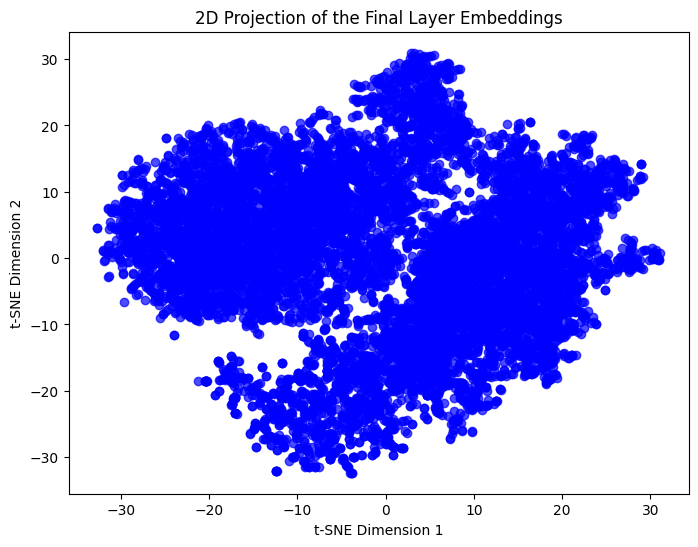

In [ ]:

layer_idx=26
layer_data =  all_mean_embeddings[layer_idx].float().numpy()

# 3. Compress the 768 hidden dimensions down to 2 dimensions for plotting
tsne = TSNE(n_components=3, random_state=42)
embeddings_2d = tsne.fit_transform(layer_data)  # Shape: [100, 2]

# 4. Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, c='blue')
plt.title("2D Projection of the Final Layer Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()


In [ ]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import umap

# 1. Load your cleaned, perfectly aligned files
all_embeddings = torch.load("clean_viz_embeddings.pt") # Shape: [num_layers, num_samples, 960]
df_clean = pd.read_csv("clean_metadata.csv")           # Metadata matching your rows

# 2. Extract a specific layer to visualize
# We extract the very last layer (-1), matching your original list comprehension logic
layer_idx = -1 
layer_embeddings = all_embeddings[layer_idx].float().numpy() # Shape: (num_samples, 960)

# 3. Configure and initialize UMAP
# n_neighbors: controls balance between local (low value) and global (high value) structure
# min_dist: controls how tightly points are packed together (lower values = tighter clusters)
reducer = umap.UMAP(
    n_neighbors=15, 
    min_dist=0.1, 
    n_components=2, 
    random_state=42
)

# Run the dimensionality reduction
print("Fitting UMAP projection...")
embeddings_2d = reducer.fit_transform(layer_embeddings) # Shape: (num_samples, 2)

# 4. Add the 2D coordinate positions back into our metadata DataFrame
df_clean['UMAP_1'] = embeddings_2d[:, 0]
df_clean['UMAP_2'] = embeddings_2d[:, 1]

# 5. Generate a polished scatter plot with Seaborn
plt.figure(figsize=(10, 7), dpi=150)
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_clean,
    x='UMAP_1',
    y='UMAP_2',
    hue='binding_mode',      # Groups points by protein binding category
    palette='viridis',       # Clean, modern color scheme
    alpha=0.8,
    s=60,                    # Size of scatter dots
    edgecolor='none'
)

# Formatting the plot layout
plt.title(f"UMAP Projection of Protein Embeddings (Layer {layer_idx})", fontsize=14, weight='bold', pad=15)
plt.xlabel("UMAP Dimension 1", fontsize=11)
plt.ylabel("UMAP Dimension 2", fontsize=11)
plt.legend(title="Binding Mode", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()

# Save the visualization plot image to disk
plt.savefig("protein_umap_plot.png", bbox_inches='tight')
plt.show()
